In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import IsolationForest
import shap
from deepctr_torch.inputs import SparseFeat, get_feature_names
from deepctr_torch.models import DeepFM
import matplotlib.pyplot as plt
import torch

# Basic setup
np.random.seed(42)
torch.manual_seed(42)

# Device setup
if torch.backends.mps.is_available():
    computation_device = torch.device("mps")
elif torch.cuda.is_available():
    computation_device = torch.device("cuda")
else:
    computation_device = torch.device("cpu")
print(f"Using device: {computation_device}")

# ============================================================================
# 1) Load JSON data and basic cleaning
# ============================================================================
amazon_fashion_data = pd.read_json("experiment_1/Amazon_Fashion.jsonl", lines=True)

# Filter out neutral ratings
amazon_fashion_data = amazon_fashion_data[amazon_fashion_data["rating"] != 3]

# Filter out older data
amazon_fashion_data = amazon_fashion_data[
    amazon_fashion_data["timestamp"] > "2015-01-01"
]

# Convert ratings into binary labels
amazon_fashion_data["rating"] = amazon_fashion_data["rating"].apply(
    lambda x: 1 if x > 3 else 0
)

# Extract date components
amazon_fashion_data["year"] = amazon_fashion_data["timestamp"].apply(lambda x: x.year)
amazon_fashion_data["month"] = amazon_fashion_data["timestamp"].apply(lambda x: x.month)
amazon_fashion_data["day"] = amazon_fashion_data["timestamp"].apply(lambda x: x.day)

# Save an unencoded copy with an explicit index
amazon_fashion_data["original_index"] = amazon_fashion_data.index
amazon_fashion_data_unencoded = amazon_fashion_data.copy()

# ============================================================================
# 2) Label encoding
# ============================================================================
categorical_features = ["parent_asin", "user_id", "year", "month", "day"]
label_encoders = {}

for feature_name in categorical_features:
    encoder = LabelEncoder()
    amazon_fashion_data[feature_name] = encoder.fit_transform(
        amazon_fashion_data[feature_name]
    )
    amazon_fashion_data[feature_name] = amazon_fashion_data[feature_name].astype(
        np.float32
    )
    label_encoders[feature_name] = encoder

amazon_fashion_data["rating"] = amazon_fashion_data["rating"].astype(np.float32)

# ============================================================================
# 3) Data splitting
# ============================================================================
reference_period_data = amazon_fashion_data[
    (amazon_fashion_data["timestamp"] > "2015-01-01")
    & (amazon_fashion_data["timestamp"] < "2020-01-01")
]
evaluation_period_data = amazon_fashion_data[
    amazon_fashion_data["timestamp"] >= "2020-01-01"
]

# Ensure evaluation data only contains known items
evaluation_period_data = evaluation_period_data[
    evaluation_period_data["parent_asin"].isin(reference_period_data["parent_asin"])
]

# ============================================================================
# 4) Subsample for SHAP
# ============================================================================
sample_size = 1000
reference_sample = reference_period_data.sample(n=sample_size, random_state=42).copy()
evaluation_sample = evaluation_period_data.sample(n=sample_size, random_state=42).copy()

# Decode columns in the sample for easier interpretation
for feature_name in categorical_features:
    reference_sample[f"{feature_name}_decoded"] = label_encoders[
        feature_name
    ].inverse_transform(reference_sample[feature_name].astype(int))
    evaluation_sample[f"{feature_name}_decoded"] = label_encoders[
        feature_name
    ].inverse_transform(evaluation_sample[feature_name].astype(int))


# ============================================================================
# 5) SHAP Explainer and Drift Detection (without PCA)
# ============================================================================
class DriftDetectorSHAP:
    def __init__(self, trained_model, feature_list):
        self.trained_model = trained_model
        self.feature_list = feature_list
        self.anomaly_detector = IsolationForest(random_state=42)

        def predict_function(feature_matrix):
            feature_matrix = feature_matrix.astype(np.float32)
            feature_df = pd.DataFrame(feature_matrix, columns=self.feature_list)
            model_inputs = {feat: feature_df[feat].values for feat in self.feature_list}
            return self.trained_model.predict(model_inputs)

        self.model_predictor = predict_function

    def calculate_shap_values(self, input_data):
        print("[DEBUG] Computing SHAP values...")
        data_matrix = input_data[self.feature_list].values.astype(np.float32)
        background_matrix = input_data.sample(n=100, random_state=42)[
            self.feature_list
        ].values.astype(np.float32)

        explainer = shap.Explainer(self.model_predictor, background_matrix)
        shap_values_full = explainer(data_matrix).values  # shape: (n, features)

        return shap_values_full

    def train_detector(self, reference_data):
        print("[DEBUG] Training drift detector...")
        shap_values = self.calculate_shap_values(reference_data)
        self.anomaly_detector.fit(shap_values)
        print("[DEBUG] Drift detector training complete.")

    def detect_drift(self, evaluation_data):
        print("[DEBUG] Running drift detection...")
        shap_values = self.calculate_shap_values(evaluation_data)
        anomaly_scores = self.anomaly_detector.decision_function(shap_values)
        drift_predictions = self.anomaly_detector.predict(shap_values)
        return anomaly_scores, drift_predictions


# ============================================================================
# 6) Train Model and Drift Detector
# ============================================================================
feature_columns = [
    SparseFeat(
        "parent_asin", amazon_fashion_data["parent_asin"].nunique(), embedding_dim=8
    ),
    SparseFeat("user_id", amazon_fashion_data["user_id"].nunique(), embedding_dim=8),
    SparseFeat("year", 10, embedding_dim=8),
    SparseFeat("month", 12, embedding_dim=8),
    SparseFeat("day", 31, embedding_dim=8),
]

linear_model_features = feature_columns
dnn_model_features = feature_columns

deepfm_feature_names = get_feature_names(linear_model_features + dnn_model_features)

model_inputs = {
    feature: amazon_fashion_data[feature].values for feature in categorical_features
}

deepfm_model = DeepFM(
    linear_model_features, dnn_model_features, task="binary", device=computation_device
)
deepfm_model.compile("adam", metrics=["AUC"], loss="binary_crossentropy")

print("Training the model...")
deepfm_model.fit(
    model_inputs,
    amazon_fashion_data["rating"].values,
    batch_size=1024,
    epochs=2,
    verbose=2,
    validation_split=0.1,
)
print("Model training complete.")

shap_drift_detector = DriftDetectorSHAP(deepfm_model, categorical_features)

shap_drift_detector.train_detector(reference_sample)
anomaly_scores, drift_detected = shap_drift_detector.detect_drift(evaluation_sample)

Using device: mps
Training the model...
mps
Train on 1950237 samples, validate on 216694 samples, 1905 steps per epoch
Epoch 1/2
61s - loss:  0.4862
Epoch 2/2
60s - loss:  0.1402
Model training complete.
[DEBUG] Training drift detector...
[DEBUG] Computing SHAP values...


ExactExplainer explainer: 1001it [01:46,  9.04it/s]                         


[DEBUG] Drift detector training complete.
[DEBUG] Running drift detection...
[DEBUG] Computing SHAP values...


ExactExplainer explainer: 1001it [02:06,  7.36it/s]                          


In [2]:
# ============================================================================
# 7) Visualization and Decoding Results
# ============================================================================
evaluation_sample["anomaly_score"] = anomaly_scores
evaluation_sample["drift_detected"] = drift_detected
print("Drift Detection Results:")
print(
    evaluation_sample[
        ["anomaly_score", "drift_detected"]
        + [f"{f}_decoded" for f in categorical_features]
    ].head()
)

Drift Detection Results:
         anomaly_score  drift_detected parent_asin_decoded  \
1411305       0.147947               1          B07Q3H5WKC   
1847521      -0.028363              -1          B00IT5J0J0   
2248862       0.071505               1          B000ML9S14   
1757336       0.089462               1          B09TXZHKLG   
2123887      -0.069354              -1          B01N5KS9S4   

                      user_id_decoded  year_decoded  month_decoded  \
1411305  AF36LG4DT6EZ3BEVHIPIHEK6D2FA          2021              5   
1847521  AGQWFEPVQ5TENZFKP7OMI5DER2HA          2021              1   
2248862  AGLGLKPZWAMCOZOWTZK5LRGRZBGA          2021             10   
1757336  AG23LROUNWY2ZSGDSAQ2SDRNJ2WA          2021              9   
2123887  AHHM5LSGVZXJDZP6HGLZGAHS6Z5Q          2020             12   

         day_decoded  
1411305           28  
1847521           22  
2248862           19  
1757336           13  
2123887           20  


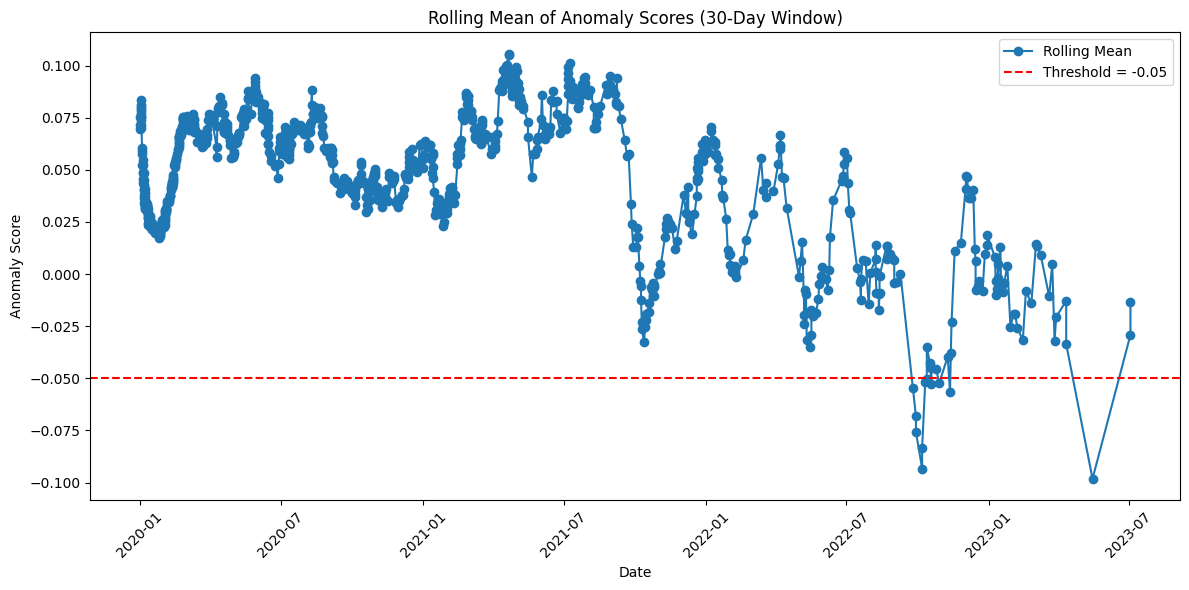

In [5]:
#
# B) Rolling 7-day mean
#
evaluation_sample.set_index("date", inplace=True)

# Compute a rolling mean over a 30-day window (you can adjust this back to 7 days if you wish)
evaluation_sample["rolling_mean"] = (
    evaluation_sample["anomaly_score"].rolling("30D").mean()
)

plt.figure(figsize=(12, 6))
plt.plot(
    evaluation_sample.index,
    evaluation_sample["rolling_mean"],
    marker="o",
    label="Rolling Mean",
)
# Add the threshold line
plt.axhline(y=-0.05, color="red", linestyle="--", label="Threshold = -0.05")

plt.title("Rolling Mean of Anomaly Scores (30-Day Window)")
plt.xlabel("Date")
plt.ylabel("Anomaly Score")
plt.xticks(rotation=45)
plt.legend()  # Make sure to show the legend
plt.tight_layout()
plt.show()

In [ ]:
#
# C) Daily Aggregation
#
# Rebuild the date column (if needed) or convert the index back to columns
evaluation_sample.reset_index(inplace=True)  # get 'date' back as a column

# Aggregate the anomaly scores per day
daily_scores = (
    evaluation_sample.groupby(evaluation_sample["date"].dt.date)["anomaly_score"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))
plt.plot(daily_scores["date"], daily_scores["anomaly_score"], marker="o")
plt.title("Average Anomaly Score per Day")
plt.xlabel("Date")
plt.ylabel("Average Anomaly Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

[DEBUG] Computing SHAP values...


ExactExplainer explainer: 1001it [02:02,  7.59it/s]                          
/var/folders/_3/jggbxqpj77x_m8nr3ll39p5r0000gn/T/ipykernel_75596/2589358262.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


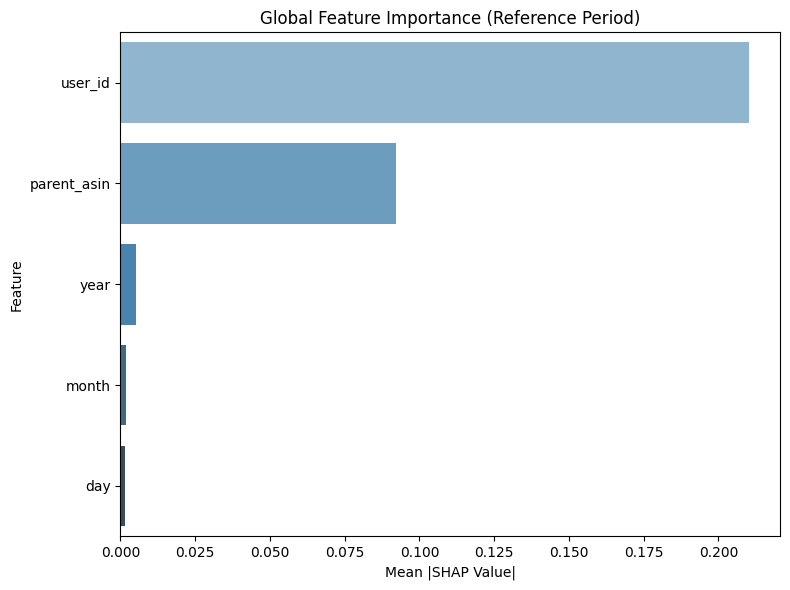

In [7]:
import seaborn as sns

# 1) Compute SHAP values for Reference Period
ref_shap_values = shap_drift_detector.calculate_shap_values(reference_sample)

# 2) Calculate mean absolute SHAP values per feature
feature_importance = np.mean(np.abs(ref_shap_values), axis=0)

# 3) Create a DataFrame for plotting
feature_names = shap_drift_detector.feature_list
importance_df = pd.DataFrame(
    {"feature": feature_names, "importance": feature_importance}
)

# 4) Sort by importance descending
importance_df.sort_values("importance", ascending=False, inplace=True)

# 5) Use seaborn (or matplotlib) for a custom bar plot
plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df, x="importance", y="feature", palette="Blues_d")

plt.title("Global Feature Importance (Reference Period)")
plt.xlabel("Mean |SHAP Value|")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

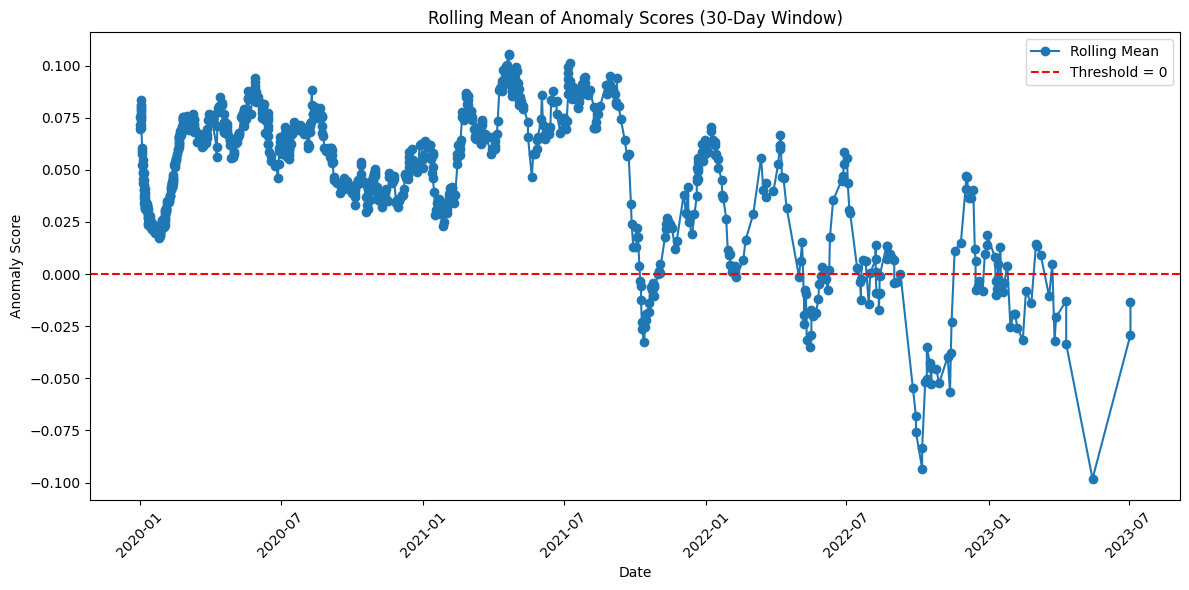

In [12]:
# B) Rolling 7-day mean (adjusted to 30-day)
# evaluation_sample.set_index("date", inplace=True)

# Compute a rolling mean over a 30-day window
evaluation_sample["rolling_mean"] = (
    evaluation_sample["anomaly_score"].rolling("30D").mean()
)

plt.figure(figsize=(12, 6))
plt.plot(
    evaluation_sample.index,
    evaluation_sample["rolling_mean"],
    marker="o",
    label="Rolling Mean",
)

# Add the threshold line at y=-0.05
plt.axhline(y=-0.00, color="red", linestyle="--", label="Threshold = 0")

plt.title("Rolling Mean of Anomaly Scores (30-Day Window)")
plt.xlabel("Date")
plt.ylabel("Anomaly Score")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()